# Numerical Computing — Assignment 6
**Newton Interpolation Polynomial**

Name: Aditya Gowari  |  Roll No: 2506

Run the cells in order — Cell 1 (imports + core functions) is used by every question below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Divided-difference table
# ---------------------------------------------------------
def divided_difference_table(x, y):
    n = len(x)
    table = np.zeros((n, n))
    table[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (table[i + 1, j - 1] - table[i, j - 1]) / (x[i + j] - x[i])
    return table


# ---------------------------------------------------------
# Newton coefficients (top row of the table)
# ---------------------------------------------------------
def newton_coefficients(table):
    return table[0, :]


# ---------------------------------------------------------
# Evaluate the Newton polynomial (nested multiplication)
# ---------------------------------------------------------
def newton_interpolation(x_data, coefficients, x):
    n = len(coefficients)
    result = coefficients[n - 1]
    for i in range(n - 2, -1, -1):
        result = coefficients[i] + (x - x_data[i]) * result
    return result


# ---------------------------------------------------------
# Evaluate the Newton polynomial AND its derivative together (Q6)
# ---------------------------------------------------------
def newton_value_and_derivative(x_data, coefficients, x):
    n = len(coefficients)
    value = coefficients[n - 1]
    derivative = 0.0
    for i in range(n - 2, -1, -1):
        derivative = value + (x - x_data[i]) * derivative
        value = coefficients[i] + (x - x_data[i]) * value
    return value, derivative


# ---------------------------------------------------------
# Independent Lagrange interpolation (Q4)
# ---------------------------------------------------------
def lagrange_interpolation(x_data, y_data, x):
    n = len(x_data)
    result = 0.0
    for i in range(n):
        term = y_data[i]
        for j in range(n):
            if i != j:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        result += term
    return result


# ---------------------------------------------------------
# Lagrange value AND derivative together (Q6)
# ---------------------------------------------------------
def lagrange_value_and_derivative(x_data, y_data, x):
    n = len(x_data)
    value = 0.0
    derivative = 0.0
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (x - x_data[j]) / (x_data[i] - x_data[j])
        value += y_data[i] * Li

        Li_derivative = 0.0
        for k in range(n):
            if k == i:
                continue
            product = 1.0
            for j in range(n):
                if j != i and j != k:
                    product *= (x - x_data[j]) / (x_data[i] - x_data[j])
            Li_derivative += product / (x_data[i] - x_data[k])
        derivative += y_data[i] * Li_derivative
    return value, derivative


# ---------------------------------------------------------
# Finite-difference derivative for unequally spaced data (Q6)
# ---------------------------------------------------------
def finite_difference_derivative(x, y):
    n = len(x)
    derivative = np.zeros(n)

    h = x[1] - x[0]
    derivative[0] = (y[1] - y[0]) / h

    for i in range(1, n - 1):
        h1 = x[i] - x[i - 1]
        h2 = x[i + 1] - x[i]
        derivative[i] = (
            -h2 / (h1 * (h1 + h2)) * y[i - 1]
            + (h2 - h1) / (h1 * h2) * y[i]
            + h1 / (h2 * (h1 + h2)) * y[i + 1]
        )

    h = x[-1] - x[-2]
    derivative[-1] = (y[-1] - y[-2]) / h

    return derivative

# ---------------------------------------------------------
# Colour palette used for every plot in this notebook
# (kept simple: one solid colour per role, no gradients)
# ---------------------------------------------------------
COLOR_EXACT    = "#2C3E50"   # dark slate  - exact / reference function
COLOR_NEWTON   = "#C0392B"   # brick red   - Newton interpolation
COLOR_LAGRANGE = "#16A085"   # teal        - Lagrange interpolation
COLOR_FD       = "#8E44AD"   # purple      - finite difference
COLOR_DATA     = "#D68910"   # amber       - data points
COLOR_ERROR    = "#C0392B"   # brick red   - error curves
COLOR_ACCENT   = "#2980B9"   # blue        - secondary curve / markers

print("Core functions and colour palette loaded.")


Core functions and colour palette loaded.


## Question 1 — Building Newton's Polynomial

$f(x) = x^2 + 2x + 1$ using $x = -2, -1, 0, 1, 2$.

In [2]:
# ---------------------------------------------------------
# Q1 data
# ---------------------------------------------------------
x1 = np.array([-2, -1, 0, 1, 2], dtype=float)
y1 = x1**2 + 2*x1 + 1

table1 = divided_difference_table(x1, y1)
coefficients1 = newton_coefficients(table1)

print("Divided-Difference Table:")
print(table1)

print("\nNewton Coefficients:")
print(coefficients1)


Divided-Difference Table:
[[ 1. -1.  1.  0.  0.]
 [ 0.  1.  1.  0.  0.]
 [ 1.  3.  1.  0.  0.]
 [ 4.  5.  0.  0.  0.]
 [ 9.  0.  0.  0.  0.]]

Newton Coefficients:
[ 1. -1.  1.  0.  0.]


In [3]:
# ---------------------------------------------------------
# Q1: evaluate at required points and compute error
# ---------------------------------------------------------
evaluation_points1 = np.array([-1.5, -0.5, 0.5, 1.5])

print("x\t\tP4(x)\t\tf(x)\t\tAbsolute Error")
for point in evaluation_points1:
    p_value = newton_interpolation(x1, coefficients1, point)
    exact_value = point**2 + 2*point + 1
    error = abs(exact_value - p_value)
    print(f"{point:.1f}\t\t{p_value:.10f}\t{exact_value:.10f}\t{error:.10e}")


x		P4(x)		f(x)		Absolute Error
-1.5		0.2500000000	0.2500000000	0.0000000000e+00
-0.5		0.2500000000	0.2500000000	0.0000000000e+00
0.5		2.2500000000	2.2500000000	0.0000000000e+00
1.5		6.2500000000	6.2500000000	0.0000000000e+00


In [33]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Divided-difference table
# ---------------------------------------------------------
def divided_difference_table(x, y):
    n = len(x)
    table = np.zeros((n, n))
    table[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (
                table[i + 1, j - 1] - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


# ---------------------------------------------------------
# Newton coefficients (top row of the table)
# ---------------------------------------------------------
def newton_coefficients(table):
    return table[0, :]


# ---------------------------------------------------------
# Evaluate the Newton polynomial
# ---------------------------------------------------------
def newton_interpolation(x_data, coefficients, x):
    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):
        result = (
            coefficients[i]
            + (x - x_data[i]) * result
        )

    return result


# ---------------------------------------------------------
# Evaluate Newton polynomial at multiple points
# ---------------------------------------------------------
def evaluate_multiple(x_data, coefficients, x_values):
    return np.array([
        newton_interpolation(x_data, coefficients, x)
        for x in x_values
    ])

In [34]:
# ---------------------------------------------------------
# Q1 data
# ---------------------------------------------------------
def f1(x):
    return x**2 + 2*x + 1


x1 = np.array([-2, -1, 0, 1, 2], dtype=float)
y1 = f1(x1)

table1 = divided_difference_table(x1, y1)
coefficients1 = newton_coefficients(table1)

print("Divided-Difference Table:")
print(table1)

print("\nNewton Coefficients:")
print(coefficients1)

Divided-Difference Table:
[[ 1. -1.  1.  0.  0.]
 [ 0.  1.  1.  0.  0.]
 [ 1.  3.  1.  0.  0.]
 [ 4.  5.  0.  0.  0.]
 [ 9.  0.  0.  0.  0.]]

Newton Coefficients:
[ 1. -1.  1.  0.  0.]


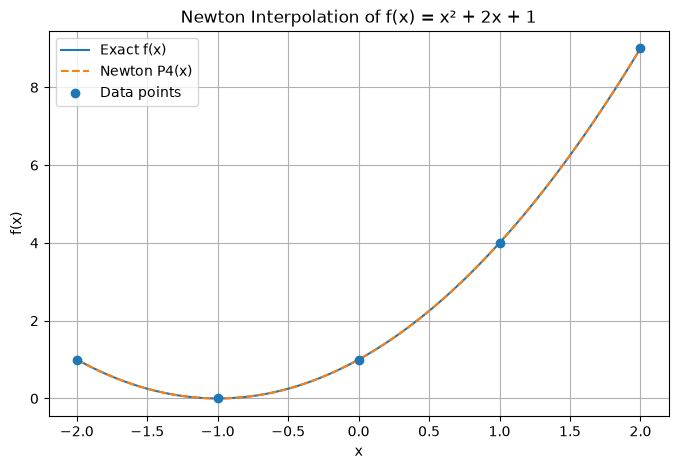

In [35]:
# ---------------------------------------------------------
# Q1 Plot: exact function vs Newton interpolation
# ---------------------------------------------------------
x_plot1 = np.linspace(-2, 2, 500)

exact_plot1 = f1(x_plot1)

interp_plot1 = evaluate_multiple(
    x1,
    coefficients1,
    x_plot1
)

plt.figure(figsize=(8, 5))

plt.plot(
    x_plot1,
    exact_plot1,
    label="Exact f(x)"
)

plt.plot(
    x_plot1,
    interp_plot1,
    "--",
    label="Newton P4(x)"
)

plt.scatter(
    x1,
    y1,
    label="Data points",
    zorder=5
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton Interpolation of f(x) = x² + 2x + 1")
plt.legend()
plt.grid(True)

plt.show()

## Question 2 — Newton Interpolation with Unequally Spaced Data

$f(x) = \sin x$ using $x = 0, 0.2, 0.55, 1.0, 1.4$.

In [4]:
# ---------------------------------------------------------
# Q2 data
# ---------------------------------------------------------
x2 = np.array([0.0, 0.2, 0.55, 1.0, 1.4])
y2 = np.sin(x2)

table2 = divided_difference_table(x2, y2)
coefficients2 = newton_coefficients(table2)

print("Divided-Difference Table:")
print(table2)

print("\nNewton Coefficients:")
print(coefficients2)


Divided-Difference Table:
[[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]
 [ 0.19866933  0.92576542 -0.27169635 -0.11521528  0.        ]
 [ 0.52268723  0.70840835 -0.40995469  0.          0.        ]
 [ 0.84147098  0.35994686  0.          0.          0.        ]
 [ 0.98544973  0.          0.          0.          0.        ]]

Newton Coefficients:
[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]


In [5]:
# ---------------------------------------------------------
# Q2: evaluate at required points
# ---------------------------------------------------------
evaluation_points2 = np.array([0.4, 0.8, 1.2])

print("x\t\tP4(x)\t\tsin(x)\t\tAbsolute Error")
for point in evaluation_points2:
    p_value = newton_interpolation(x2, coefficients2, point)
    exact_value = np.sin(point)
    error = abs(exact_value - p_value)
    print(f"{point:.1f}\t\t{p_value:.10f}\t{exact_value:.10f}\t{error:.10e}")


x		P4(x)		sin(x)		Absolute Error
0.4		0.3894673523	0.3894183423	4.9010015934e-05
0.8		0.7172626697	0.7173560909	9.3421162543e-05
1.2		0.9322300290	0.9320390860	1.9094302214e-04


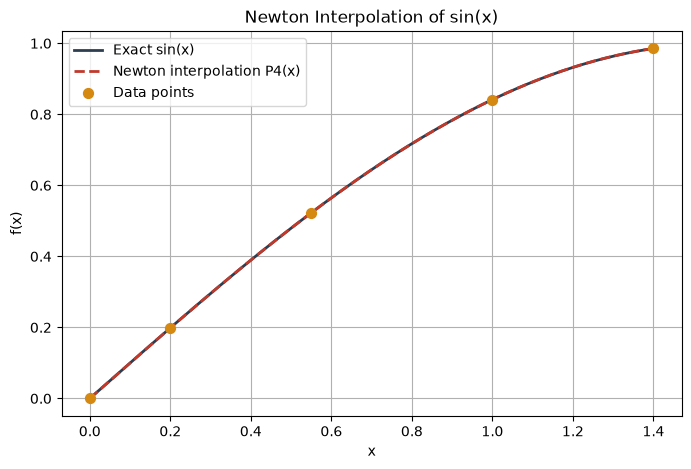

In [6]:
# ---------------------------------------------------------
# Q2 Plot 1: exact sin(x) vs Newton interpolation + data points
# ---------------------------------------------------------
x_plot2 = np.linspace(0, 1.4, 500)
exact2 = np.sin(x_plot2)
interp2 = np.array([newton_interpolation(x2, coefficients2, p) for p in x_plot2])

plt.figure(figsize=(8, 5))
plt.plot(x_plot2, exact2, label="Exact sin(x)", color=COLOR_EXACT, linewidth=2)
plt.plot(x_plot2, interp2, label="Newton interpolation P4(x)", color=COLOR_NEWTON, linewidth=2, linestyle="--")
plt.scatter(x2, y2, label="Data points", color=COLOR_DATA, zorder=5, s=50)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton Interpolation of sin(x)")
plt.legend()
plt.grid(True)
plt.show()


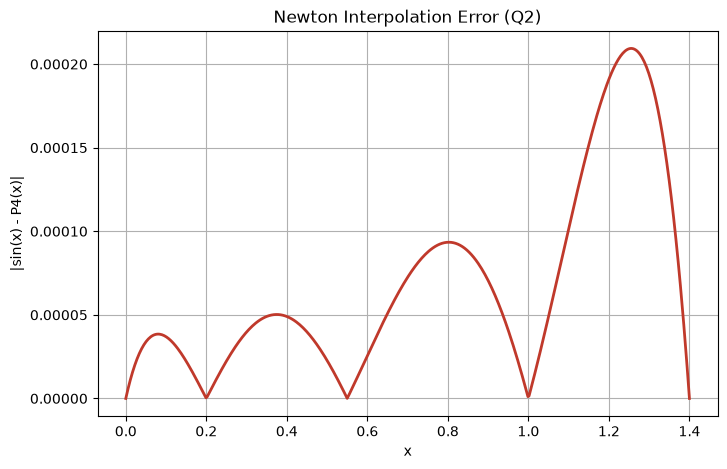

Maximum error: 2.0935112672e-04 at x = 1.254108


In [7]:
# ---------------------------------------------------------
# Q2 Plot 2: interpolation error over the interval
# ---------------------------------------------------------
error2 = np.abs(exact2 - interp2)

plt.figure(figsize=(8, 5))
plt.plot(x_plot2, error2, color=COLOR_ERROR, linewidth=2)
plt.xlabel("x")
plt.ylabel("|sin(x) - P4(x)|")
plt.title("Newton Interpolation Error (Q2)")
plt.grid(True)
plt.show()

max_index2 = np.argmax(error2)
print(f"Maximum error: {error2[max_index2]:.10e} at x = {x_plot2[max_index2]:.6f}")


## Question 3 — Does More Data Always Mean Better Interpolation?

$f(x) = e^x$ using the first 4, 8, 12 and 16 of the 16 given unequally spaced points.

In [8]:
# ---------------------------------------------------------
# Q3 data
# ---------------------------------------------------------
x_all3 = np.array([
    -1.00, -0.92, -0.75, -0.61, -0.48, -0.31, -0.17, 0.02,
     0.15,  0.29,  0.43,  0.58,  0.67,  0.81,  0.93, 1.00
])
y_all3 = np.exp(x_all3)

x_eval3 = np.linspace(-1, 1, 500)
exact3 = np.exp(x_eval3)

number_of_points3 = [4, 8, 12, 16]
results3 = []          # (num_points, degree, max_error, location)
interpolations3 = {}   # num_points -> array of P_n(x_eval3)

for num_points in number_of_points3:
    x_data = x_all3[:num_points]
    y_data = y_all3[:num_points]

    table = divided_difference_table(x_data, y_data)
    coefficients = newton_coefficients(table)

    p_values = np.array([newton_interpolation(x_data, coefficients, p) for p in x_eval3])
    error = np.abs(exact3 - p_values)

    max_index = np.argmax(error)
    results3.append([num_points, num_points - 1, error[max_index], x_eval3[max_index]])
    interpolations3[num_points] = p_values

print("Interpolation Accuracy Comparison")
print("----------------------------------")
print("Points\tDegree\tMaximum Error\tLocation")
for r in results3:
    print(f"{r[0]}\t{r[1]}\t{r[2]:.10e}\t{r[3]:.6f}")


Interpolation Accuracy Comparison
----------------------------------
Points	Degree	Maximum Error	Location
4	3	3.0046021417e-01	1.000000
8	7	4.2437931709e-04	1.000000
12	11	6.4115321941e-09	1.000000
16	15	8.8817841970e-16	0.891784


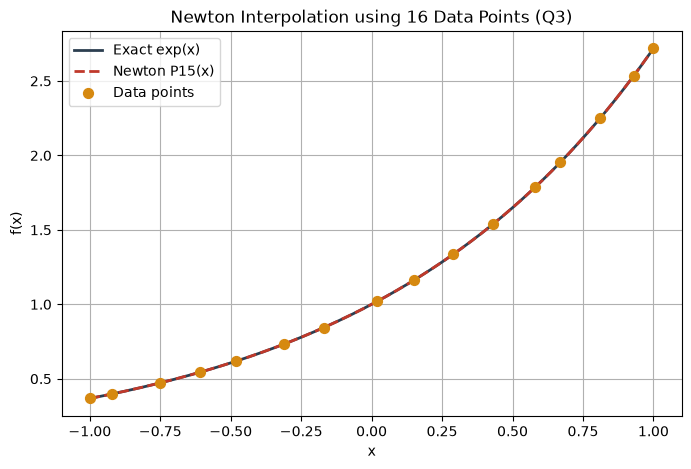

In [9]:
# ---------------------------------------------------------
# Q3 Plot 1: exact e^x vs the degree-15 Newton polynomial (all 16 points)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_eval3, exact3, label="Exact exp(x)", color=COLOR_EXACT, linewidth=2)
plt.plot(x_eval3, interpolations3[16], label="Newton P15(x)", color=COLOR_NEWTON, linewidth=2, linestyle="--")
plt.scatter(x_all3, y_all3, label="Data points", color=COLOR_DATA, zorder=5, s=50)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton Interpolation using 16 Data Points (Q3)")
plt.legend()
plt.grid(True)
plt.show()


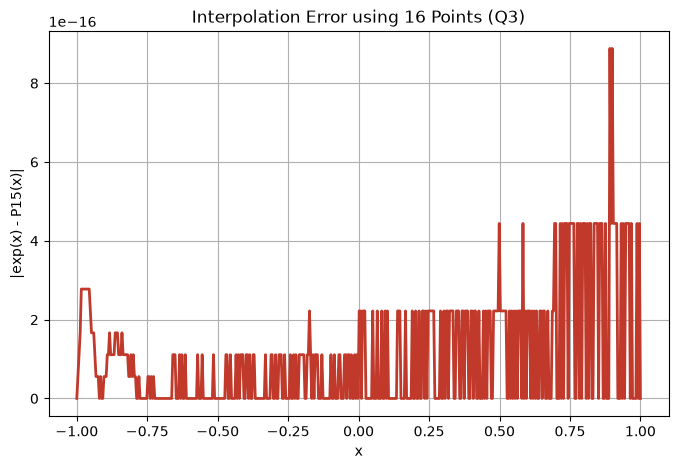

In [10]:
# ---------------------------------------------------------
# Q3 Plot 2: error for the 16-point (degree-15) interpolation
# ---------------------------------------------------------
error_p15 = np.abs(exact3 - interpolations3[16])

plt.figure(figsize=(8, 5))
plt.plot(x_eval3, error_p15, color=COLOR_ERROR, linewidth=2)
plt.xlabel("x")
plt.ylabel("|exp(x) - P15(x)|")
plt.title("Interpolation Error using 16 Points (Q3)")
plt.grid(True)
plt.show()


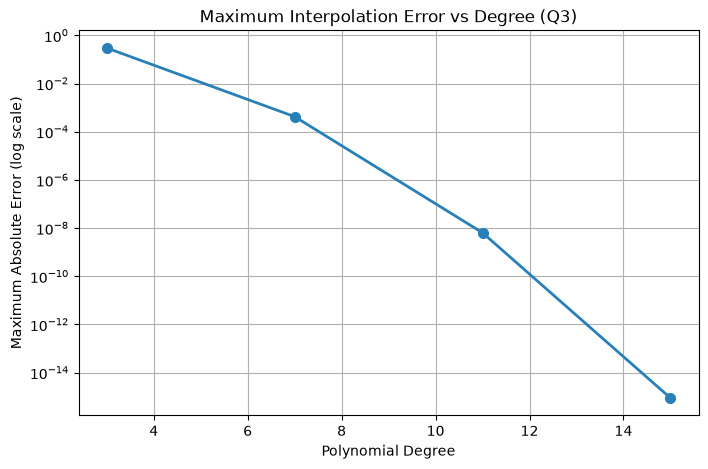

In [11]:
# ---------------------------------------------------------
# Q3 Plot 3: maximum error vs polynomial degree
# ---------------------------------------------------------
degrees3 = [r[1] for r in results3]
max_errors3 = [r[2] for r in results3]

plt.figure(figsize=(8, 5))
plt.plot(degrees3, max_errors3, marker="o", color=COLOR_ACCENT, linewidth=2, markersize=7)
plt.yscale("log")
plt.xlabel("Polynomial Degree")
plt.ylabel("Maximum Absolute Error (log scale)")
plt.title("Maximum Interpolation Error vs Degree (Q3)")
plt.grid(True)
plt.show()


## Question 4 — Newton vs Lagrange: Are They Really Different?

$f(x) = \dfrac{1}{1+x^2}$ using 17 equally spaced points on $[-4, 4]$.

In [12]:
# ---------------------------------------------------------
# Q4 data
# ---------------------------------------------------------
def f4(x):
    return 1 / (1 + x**2)

x4 = np.arange(-4, 4.01, 0.5)
y4 = f4(x4)

table4 = divided_difference_table(x4, y4)
coefficients4 = newton_coefficients(table4)

x_eval4 = np.linspace(-4, 4, 200)
exact4 = f4(x_eval4)

newton_values4 = np.array([newton_interpolation(x4, coefficients4, p) for p in x_eval4])
lagrange_values4 = np.array([lagrange_interpolation(x4, y4, p) for p in x_eval4])

newton_error4 = np.abs(exact4 - newton_values4)
lagrange_error4 = np.abs(exact4 - lagrange_values4)

print("Maximum Errors")
print("--------------")
print(f"Max Newton Error   = {np.max(newton_error4):.10e}")
print(f"Max Lagrange Error = {np.max(lagrange_error4):.10e}")


Maximum Errors
--------------
Max Newton Error   = 5.8871887906e+00
Max Lagrange Error = 5.8871887906e+00


In [13]:
# ---------------------------------------------------------
# Q4: comparison at the required points
# ---------------------------------------------------------
comparison_points4 = np.array([-3.75, -2.25, -0.75, 0.75, 2.25, 3.75])

print("x\t\tExact\t\tNewton\t\tLagrange")
for point in comparison_points4:
    exact = f4(point)
    newton = newton_interpolation(x4, coefficients4, point)
    lagrange = lagrange_interpolation(x4, y4, point)
    print(f"{point:.2f}\t\t{exact:.10f}\t{newton:.10f}\t{lagrange:.10f}")


x		Exact		Newton		Lagrange
-3.75		0.0663900415	-4.1253119378	-4.1253119378
-2.25		0.1649484536	0.1919788740	0.1919788740
-0.75		0.6400000000	0.6362738985	0.6362738985
0.75		0.6400000000	0.6362738985	0.6362738985
2.25		0.1649484536	0.1919788740	0.1919788740
3.75		0.0663900415	-4.1253119378	-4.1253119378


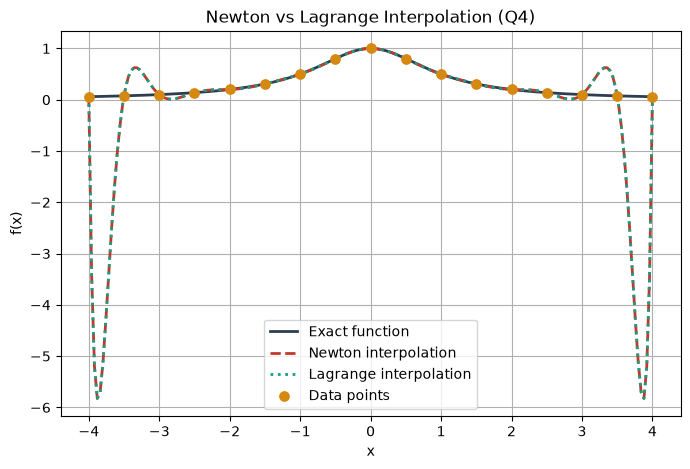

In [14]:
# ---------------------------------------------------------
# Q4 Plot 1: exact function, Newton interpolation, Lagrange interpolation
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_eval4, exact4, label="Exact function", color=COLOR_EXACT, linewidth=2)
plt.plot(x_eval4, newton_values4, label="Newton interpolation", color=COLOR_NEWTON, linewidth=2, linestyle="--")
plt.plot(x_eval4, lagrange_values4, label="Lagrange interpolation", color=COLOR_LAGRANGE, linewidth=2, linestyle=":")
plt.scatter(x4, y4, label="Data points", color=COLOR_DATA, zorder=5, s=45)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton vs Lagrange Interpolation (Q4)")
plt.legend()
plt.grid(True)
plt.show()


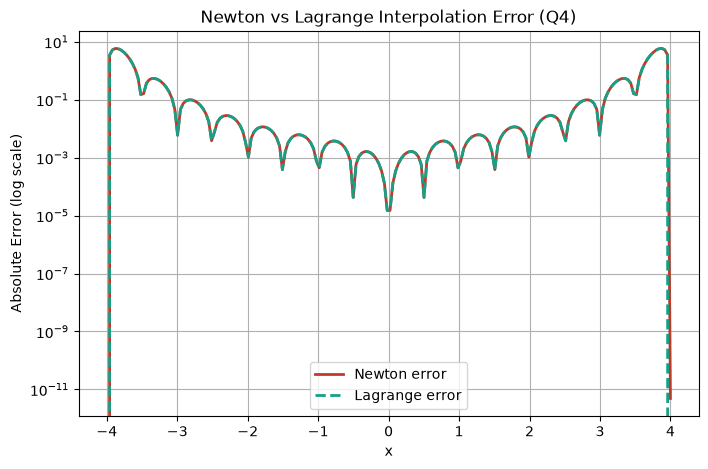

In [15]:
# ---------------------------------------------------------
# Q4 Plot 2: Newton error vs Lagrange error
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_eval4, newton_error4, label="Newton error", color=COLOR_NEWTON, linewidth=2)
plt.plot(x_eval4, lagrange_error4, label="Lagrange error", color=COLOR_LAGRANGE, linewidth=2, linestyle="--")
plt.yscale("log")
plt.xlabel("x")
plt.ylabel("Absolute Error (log scale)")
plt.title("Newton vs Lagrange Interpolation Error (Q4)")
plt.legend()
plt.grid(True)
plt.show()


## Question 5 — Newton Interpolation and Numerical Error

$f(x) = \dfrac{1}{1+25x^2}$, equally spaced points, degrees $n = 4, 8, 12, 16, 20$.

In [16]:
# ---------------------------------------------------------
# Q5 data and experiment
# ---------------------------------------------------------
def f5(x):
    return 1 / (1 + 25*x**2)

degrees5 = [4, 8, 12, 16, 20]

x_eval5 = np.linspace(-1, 1, 500)
exact5 = f5(x_eval5)

maximum_errors5 = []
error_locations5 = []
interpolations5 = {}
errors5 = {}

for n in degrees5:
    x_data = -1 + 2 * np.arange(n + 1) / n
    y_data = f5(x_data)

    table = divided_difference_table(x_data, y_data)
    coefficients = newton_coefficients(table)

    p_values = np.array([newton_interpolation(x_data, coefficients, p) for p in x_eval5])
    error = np.abs(exact5 - p_values)

    max_index = np.argmax(error)
    maximum_errors5.append(error[max_index])
    error_locations5.append(x_eval5[max_index])

    interpolations5[n] = p_values
    errors5[n] = error

print("Newton Interpolation Error Analysis")
print("------------------------------------")
print("Degree\tPoints\tMaximum Error\tLocation")
for n, max_error, location in zip(degrees5, maximum_errors5, error_locations5):
    print(f"{n}\t{n+1}\t{max_error:.10e}\t{location:.6f}")


Newton Interpolation Error Analysis
------------------------------------
Degree	Points	Maximum Error	Location
4	5	4.3835144567e-01	-0.795591
8	9	1.0451657689e+00	-0.919840
12	13	3.6628680036e+00	-0.951904
16	17	1.4387236564e+01	0.967936
20	21	5.9771050535e+01	-0.975952


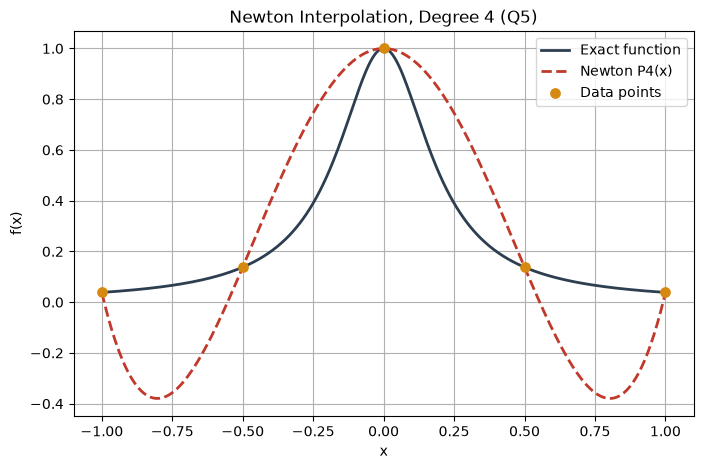

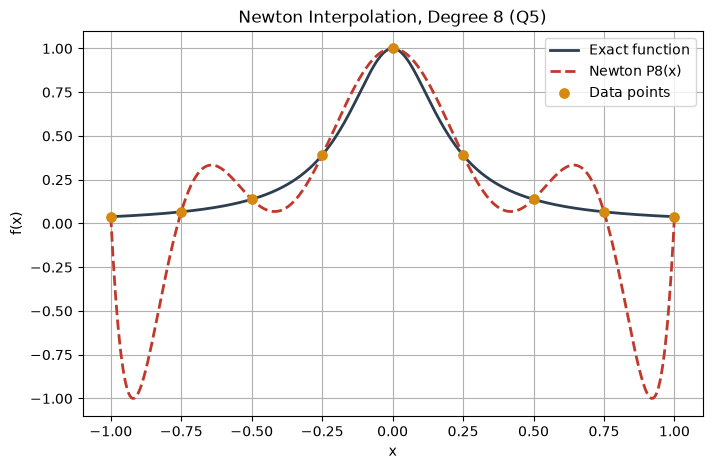

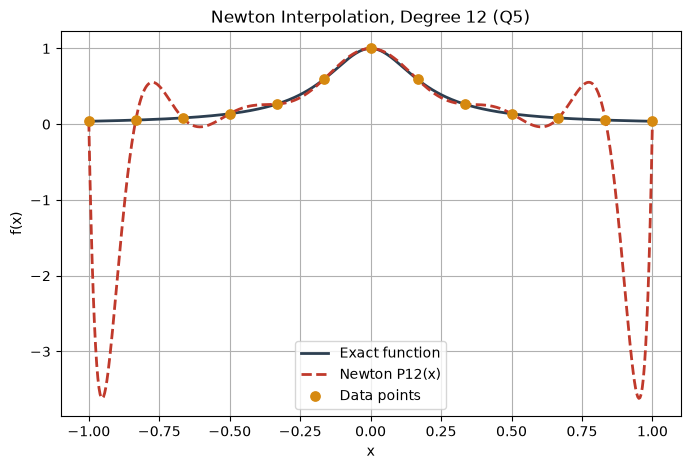

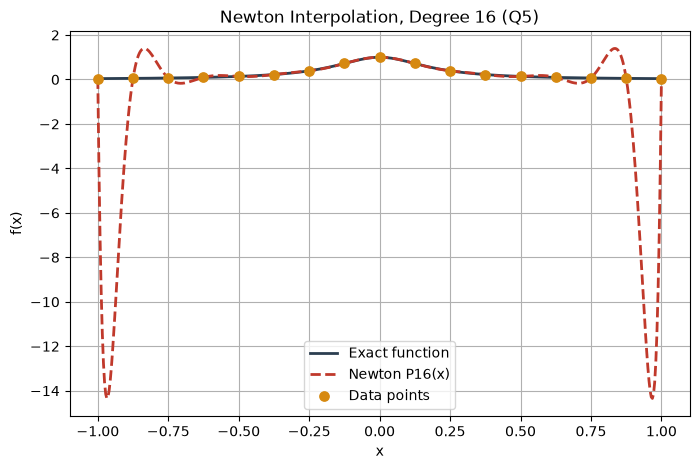

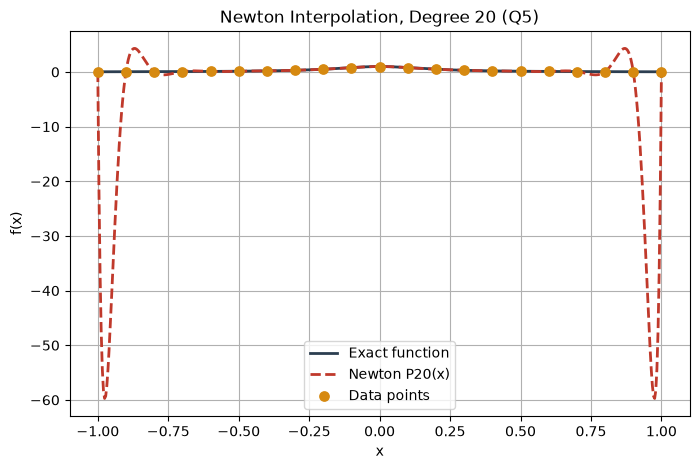

In [17]:
# ---------------------------------------------------------
# Q5 Plot 1: exact function vs interpolation, for each degree
# ---------------------------------------------------------
for n in degrees5:
    x_data = -1 + 2 * np.arange(n + 1) / n
    y_data = f5(x_data)

    plt.figure(figsize=(8, 5))
    plt.plot(x_eval5, exact5, label="Exact function", color=COLOR_EXACT, linewidth=2)
    plt.plot(x_eval5, interpolations5[n], label=f"Newton P{n}(x)", color=COLOR_NEWTON, linewidth=2, linestyle="--")
    plt.scatter(x_data, y_data, label="Data points", color=COLOR_DATA, zorder=5, s=45)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(f"Newton Interpolation, Degree {n} (Q5)")
    plt.legend()
    plt.grid(True)
    plt.show()


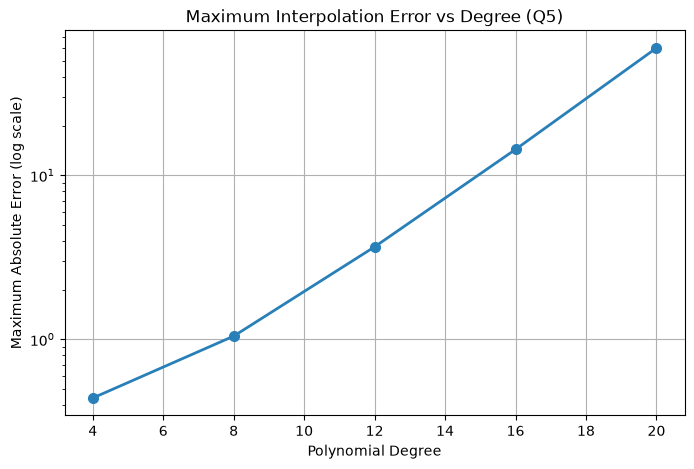

In [18]:
# ---------------------------------------------------------
# Q5 Plot 2: maximum error vs degree
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(degrees5, maximum_errors5, marker="o", color=COLOR_ACCENT, linewidth=2, markersize=7)
plt.yscale("log")
plt.xlabel("Polynomial Degree")
plt.ylabel("Maximum Absolute Error (log scale)")
plt.title("Maximum Interpolation Error vs Degree (Q5)")
plt.grid(True)
plt.show()


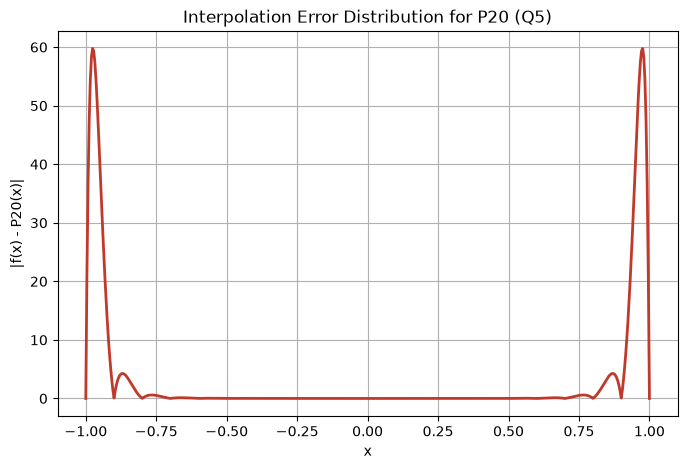

In [19]:
# ---------------------------------------------------------
# Q5 Plot 3: error distribution for n = 20
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_eval5, errors5[20], color=COLOR_ERROR, linewidth=2)
plt.xlabel("x")
plt.ylabel("|f(x) - P20(x)|")
plt.title("Interpolation Error Distribution for P20 (Q5)")
plt.grid(True)
plt.show()


## Question 6 — Numerical Differentiation Using Newton Interpolation

Same data as Q2: $f(x) = \sin x$ at $x = 0, 0.2, 0.55, 1.0, 1.4$. Differentiate $P_4(x)$ algorithmically and compare with $\cos x$.

In [20]:
# ---------------------------------------------------------
# Q6: reuse Q2 data and coefficients
# ---------------------------------------------------------
x6 = x2
y6 = y2
table6 = table2
coefficients6 = coefficients2

evaluation_points6 = np.array([0.3, 0.7, 1.1])

print("x\t\tP4(x)\t\tP4'(x)\t\tcos(x)\t\tAbs Error\tRel Error")
for point in evaluation_points6:
    p_value, derivative = newton_value_and_derivative(x6, coefficients6, point)
    exact_derivative = np.cos(point)
    absolute_error = abs(exact_derivative - derivative)
    relative_error = absolute_error / abs(exact_derivative)
    print(f"{point:.1f}\t\t{p_value:.10f}\t{derivative:.10f}\t{exact_derivative:.10f}\t"
          f"{absolute_error:.10e}\t{relative_error:.10e}")


x		P4(x)		P4'(x)		cos(x)		Abs Error	Rel Error
0.3		0.2955599305	0.9556103454	0.9553364891	2.7385628739e-04	2.8665950741e-04
0.7		0.6441452289	0.7644649002	0.7648421873	3.7728709349e-04	4.9328750396e-04
1.1		0.8913088992	0.4546473193	0.4535961214	1.0511978761e-03	2.3174754511e-03


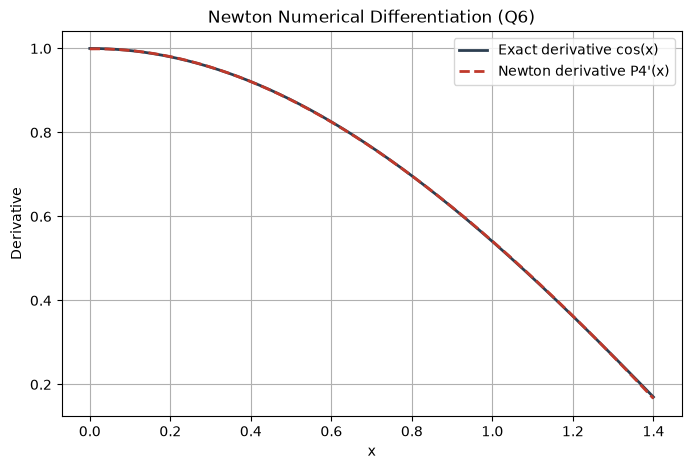

In [28]:
# ---------------------------------------------------------
# Q6 Plot 1: exact derivative vs Newton derivative
# ---------------------------------------------------------
x_eval6 = np.linspace(0, 1.4, 500)
exact_derivative6 = np.cos(x_eval6)
newton_derivative6 = np.array([newton_value_and_derivative(x6, coefficients6, p)[1] for p in x_eval6])

plt.figure(figsize=(8, 5))
plt.plot(x_eval6, exact_derivative6, label="Exact derivative cos(x)", color=COLOR_EXACT, linewidth=2)
plt.plot(x_eval6, newton_derivative6, label="Newton derivative P4'(x)", color=COLOR_NEWTON, linewidth=2, linestyle="--")
plt.xlabel("x")
plt.ylabel("Derivative")
plt.title("Newton Numerical Differentiation (Q6)")
plt.legend()
plt.grid(True)
plt.show()


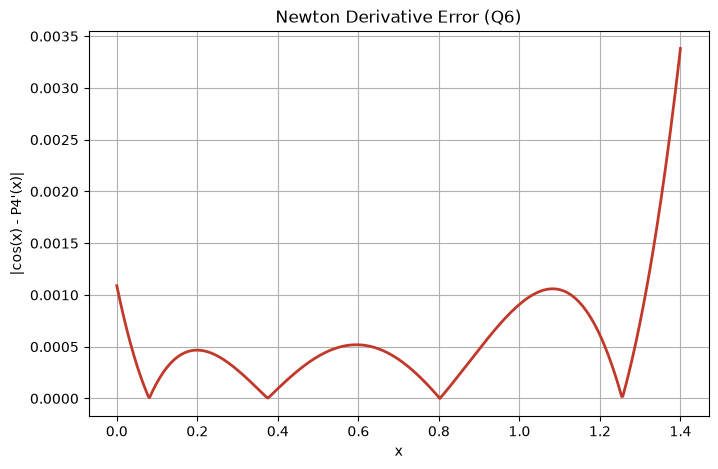

Maximum derivative error: 3.3815739590e-03 at x = 1.400000


In [22]:
# ---------------------------------------------------------
# Q6 Plot 2: derivative error
# ---------------------------------------------------------
derivative_error6 = np.abs(exact_derivative6 - newton_derivative6)

plt.figure(figsize=(8, 5))
plt.plot(x_eval6, derivative_error6, color=COLOR_ERROR, linewidth=2)
plt.xlabel("x")
plt.ylabel("|cos(x) - P4'(x)|")
plt.title("Newton Derivative Error (Q6)")
plt.grid(True)
plt.show()

max_index6 = np.argmax(derivative_error6)
print(f"Maximum derivative error: {derivative_error6[max_index6]:.10e} at x = {x_eval6[max_index6]:.6f}")


In [23]:
# ---------------------------------------------------------
# Q6: compare Newton, Lagrange and finite-difference derivatives
# ---------------------------------------------------------
fd_derivative6 = finite_difference_derivative(x6, y6)

newton_derivative_data6 = np.array([newton_value_and_derivative(x6, coefficients6, p)[1] for p in x6])
lagrange_derivative_data6 = np.array([lagrange_value_and_derivative(x6, y6, p)[1] for p in x6])
exact_derivative_data6 = np.cos(x6)

print("Three-Method Derivative Comparison")
print("-" * 90)
print("x\t\tExact\t\tFinite Difference\tLagrange\tNewton")
for i in range(len(x6)):
    print(f"{x6[i]:.2f}\t\t{exact_derivative_data6[i]:.10f}\t"
          f"{fd_derivative6[i]:.10f}\t\t{lagrange_derivative_data6[i]:.10f}\t{newton_derivative_data6[i]:.10f}")

fd_error6 = np.abs(exact_derivative_data6 - fd_derivative6)
lagrange_error6 = np.abs(exact_derivative_data6 - lagrange_derivative_data6)
newton_error_data6 = np.abs(exact_derivative_data6 - newton_derivative_data6)

print("\nMaximum Errors")
print("-" * 40)
print(f"Finite Difference : {np.max(fd_error6):.10e}")
print(f"Lagrange          : {np.max(lagrange_error6):.10e}")
print(f"Newton            : {np.max(newton_error_data6):.10e}")


Three-Method Derivative Comparison
------------------------------------------------------------------------------------------
x		Exact		Finite Difference	Lagrange	Newton
0.00		1.0000000000	0.9933466540		0.9989108160	0.9989108160
0.20		0.9800665778	0.9687716610		0.9805334016	0.9805334016
0.55		0.8525245221	0.8306717021		0.8520316924	0.8520316924
1.00		0.5403023059	0.5239287375		0.5412108614	0.5412108614
1.40		0.1699671429	0.3599468630		0.1665855689	0.1665855689

Maximum Errors
----------------------------------------
Finite Difference : 1.8997972005e-01
Lagrange          : 3.3815739590e-03
Newton            : 3.3815739590e-03


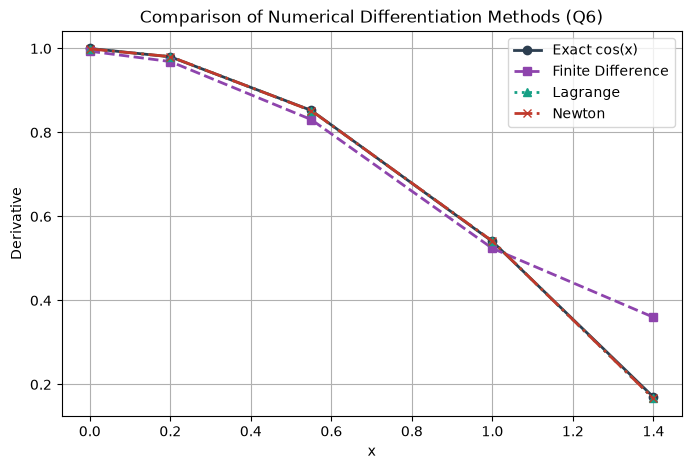

In [24]:
# ---------------------------------------------------------
# Q6 Plot 3: three derivative methods at the data points
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x6, exact_derivative_data6, marker="o", label="Exact cos(x)", color=COLOR_EXACT, linewidth=2)
plt.plot(x6, fd_derivative6, marker="s", label="Finite Difference", color=COLOR_FD, linewidth=2, linestyle="--")
plt.plot(x6, lagrange_derivative_data6, marker="^", label="Lagrange", color=COLOR_LAGRANGE, linewidth=2, linestyle=":")
plt.plot(x6, newton_derivative_data6, marker="x", label="Newton", color=COLOR_NEWTON, linewidth=2, linestyle="-.")
plt.xlabel("x")
plt.ylabel("Derivative")
plt.title("Comparison of Numerical Differentiation Methods (Q6)")
plt.legend()
plt.grid(True)
plt.show()


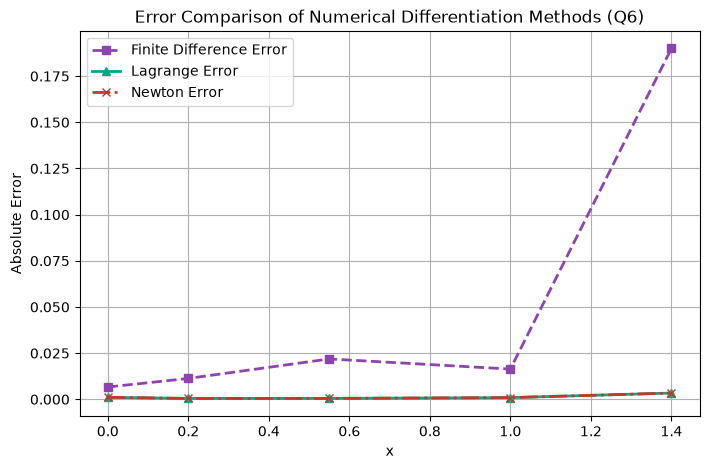

In [26]:
# ---------------------------------------------------------
# Q6 Plot 4: error comparison of the three methods
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x6, fd_error6, marker="s", label="Finite Difference Error", color=COLOR_FD, linewidth=2, linestyle="--")
plt.plot(x6, lagrange_error6, marker="^", label="Lagrange Error", color=COLOR_LAGRANGE, linewidth=2, linestyle="-")
plt.plot(x6, newton_error_data6, marker="x", label="Newton Error", color=COLOR_NEWTON, linewidth=2, linestyle="-.")
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Error Comparison of Numerical Differentiation Methods (Q6)")
plt.legend()
plt.grid(True)
plt.show()
